# Types of Linear Regression 

## Simple Linear Regression 

It is used when we want to predict a target value (dependent variable) using only one input feature (independent variable). It assumes a straight-line relationship between the two.

Simple linear regression aims to describe how one variable i.e the dependent variable changes in relation with refrences to the independent variable. For example consider a scenario where a company wants to predict sales based on advertising expenditure. By using simple linear regression the company can determine if an increase in advertising leads to higher sales or not.

### The Model

$$Y = \beta_0 + \beta_1 X + \varepsilon$$

- $Y$ — the outcome you're trying to predict or explain
- $X$ — the input variable used to predict $Y$
- $\beta_0$ (intercept) — predicted value of $Y$ when $X = 0$
- $\beta_1$ (slope) — change in $Y$ for each one-unit increase in $X$
- $\varepsilon$ (error term) — difference between actual and predicted $Y$

### How It Works

The method finds the line that best fits the data by minimizing the **sum of squared residuals** — this is called the **least squares method**:

$$\min \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Example

Predicting weight from height:

$$\text{Weight} = 50 + 0.9 \times \text{Height}$$

For every additional unit of height, weight increases by 0.9 units on average.

### Key Assumptions

1. **Linearity** — relationship between $X$ and $Y$ is linear
2. **Independence** — observations don't influence each other
3. **Homoscedasticity** — constant variance of errors across $X$
4. **Normality** — residuals are approximately normally distributed

### Evaluating the Model

| Metric | What it tells you |
|---|---|
| $R^2$ | Proportion of variance in $Y$ explained by $X$ (0 to 1) |
| p-value on $\beta_1$ | Whether the slope is statistically significant |
| Residual plots | Visual check of assumptions |

**Real Life example**

- Advertising spend vs. sales revenue — predicting how much sales increase for every additional $1,000 spent on ads

- Interest rates vs. housing prices — modeling how home prices shift as mortgage rates change

- Age vs. blood pressure — predicting blood pressure increase per year of age

- Hours of exercise vs. resting heart rate — modeling fitness impact on cardiovascular health







In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

df = pd.DataFrame({
    'ad_spend': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'sales':    [55, 68, 75, 88, 95, 108, 115, 128, 135, 148]
})

X = df[['ad_spend']]   # predictor (must be 2D)
y = df['sales']        # outcome

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")
print(f"R²: {r2_score(y, model.predict(X)):.4f}")

Intercept: 35.91
Slope: 2.02
R²: 0.9974


## Feature Selection

**Feature selection** is the process of identifying which input variables (features) actually contribute meaningful predictive power to a model, and removing those that don't.

### Why It Matters

Including irrelevant or redundant features can:
- **Increase overfitting** — the model learns noise instead of real patterns
- **Slow down training** — more features means more computation
- **Reduce interpretability** — harder to explain a model with many variables
- **Introduce multicollinearity** — correlated features destabilize coefficient estimates

---

## How Features Were Decided for the Model

Feature selection is a combination of domain judgment, statistical checks, and empirical testing. The general process:

### 1. Domain Reasoning
Before any statistics, each candidate feature is evaluated for whether it plausibly influences the outcome. Features with a clear logical link to the target are kept as candidates; features with no reasonable connection are dropped early.

### 2. Removing Unusable Features
Some features are excluded outright because they can't contribute meaningfully:
- Features with a large proportion of missing values
- Features with little to no variance (nearly constant across records)
- Identifier-type fields (IDs, irrelevant timestamps) with no predictive signal

### 3. Testing Relationship with the Target
- **Numeric features** → correlation with the target variable
- **Categorical features** → group comparisons (e.g., ANOVA) or visualizing how the target varies across categories

Features showing little to no relationship with the target are deprioritized.

### 4. Checking for Multicollinearity
If two or more features are highly correlated with each other, they carry overlapping information. Keeping all of them adds noise without adding predictive value — typically only one representative feature is retained.

### 5. Statistical / Algorithmic Selection Methods

| Method Type | Examples | Notes |
|---|---|---|
| **Filter** | Correlation, Mutual Information, Chi-squared | Fast, model-independent |
| **Wrapper** | Forward Selection, Backward Elimination, RFE | Tests subsets directly against model performance |
| **Embedded** | Lasso (L1), Tree-based feature importance | Selection happens during training |

### 6. Empirical Validation
The final decision is confirmed by comparing model performance ($R^2$, RMSE, accuracy) **with** and **without** each feature on a held-out validation set. If removing a feature doesn't meaningfully hurt performance, it's excluded.

### 7. Iteration
Feature selection is rarely a one-time step. As the model evolves, features are re-evaluated — some re-engineered and added back, others dropped after further testing.

---

**Goal:** Keep only the features that add real predictive value, while minimizing redundancy, noise, and unnecessary model complexity.

## Multicollinearity in Regression Analysis

**Multicollinearity** occurs when two or more independent variables (predictors) in a regression model are highly correlated with each other. This violates the assumption that predictors should be independent of one another, and it creates problems when trying to estimate each variable's individual effect on the outcome.

---

### Causes of Multicollinearity

1. **Correlation among predictors** — when one predictor can be closely estimated from another, it becomes difficult to isolate each variable's individual contribution to the model.
2. **Overparameterization** — including too many predictors relative to the number of observations, which introduces redundancy and inflates the variance of coefficient estimates.
3. **Data collection issues** — variables that are inherently linked or measured in overlapping ways can introduce correlation unintentionally.

---

### Detecting Multicollinearity

| Method | How It Works |
|---|---|
| **Correlation Matrix** | Calculates pairwise correlation coefficients between predictors; values close to +1 or -1 signal strong linear relationships |
| **Variance Inflation Factor (VIF)** | Measures how much a coefficient's variance is inflated due to correlation with other predictors. A VIF above 5–10 is generally considered a warning sign |

---

### Effects of Multicollinearity

- **Unstable coefficient estimates** — the model struggles to separate the individual effect of each correlated variable, sometimes producing coefficients with unexpected or flipped signs
- **Inflated standard errors** — coefficient estimates become less precise and confidence intervals widen, making it harder to assess statistical significance
- **Reduced interpretability** — the partial effect of each predictor becomes distorted, making it difficult to draw clear conclusions from the model

---

### Mitigating Multicollinearity

1. **Remove highly correlated predictors** — identified via correlation matrices or VIF scores; dropping redundant variables often has minimal impact on overall model accuracy
2. **Principal Component Analysis (PCA)** — transforms correlated variables into a smaller set of uncorrelated components, useful when many predictors are interrelated
3. **Ridge Regression (L2 regularization)** — penalizes large coefficients, shrinking their impact while still allowing all variables to remain in the model
4. **Increase sample size** — more data points can help the model better distinguish the independent effects of correlated predictors

---

**Key takeaway:** Multicollinearity doesn't necessarily hurt a model's overall predictive accuracy, but it undermines the reliability and interpretability of individual coefficient estimates — which matters greatly when the goal is to explain *why* a model makes the predictions it does (e.g., in marketing analytics, understanding which specific factors drive customer behavior).

### Pearson correlation 

The Pearson correlation coefficient (PCC) is used for measuring the strength and direction of a linear relationship between two variables.

It helps determine how closely changes in one variable are associated with changes in another.
Widely used in data analysis, research, and decision-making to identify patterns and relationships in data.

A key point is that Pearson’s correlation measures linear relationships only. If two variables follow a nonlinear pattern, the correlation coefficient may be close to zero even when the variables are clearly related. In other words, r = 0 does not necessarily mean that no relationship exists; it means there is no linear relationship between the variables.

## Bias and Variance in Machine Learning 

Bias and Variance are two fundamental concepts that help explain a model’s prediction errors in machine learning. Bias refers to the error caused by oversimplifying a model while variance refers to the error from making the model too sensitive to training data.

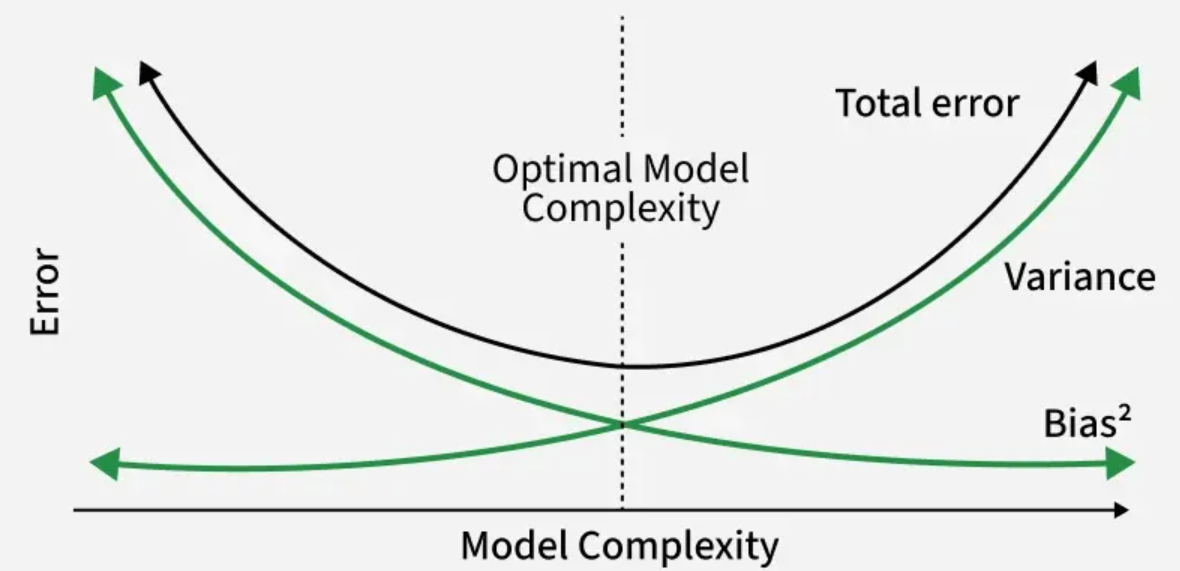

### Bias 

Bias in machine learning models refers to the error due to overly simplistic assumptions in the learning algorithm. It occurs when a model doesn’t capture all the complexities and patterns in the data, resulting in a difference between the average prediction of the model and the correct value.

**Underfitting explained**: Underfitting is a direct consequence of high bias. It happens when the model is too simple, leading to poor performance on both training and unseen data. The model fails to learn the underlying trends in the data, making its predictions generally inaccurate.

Examples of high bias in models:

- Linear models, like linear regression, are used on non-linear data.
- Simplistic decision trees have very few nodes.

Imagine you're predicting house prices based on square footage, number of bedrooms, location, and age of the house. A high-bias model might only use square footage and ignore everything else. It assumes that square footage alone determines price, which is way too simple.

The result is a model that performs poorly on both training data and new data because it can't capture the complexity of real house prices.

Linear regression with few features is a classic high-bias model. Decision trees with very limited depth also tend to have high bias because they can't split the data enough times to find nuanced patterns.

High bias means your model isn't learning enough from the data, but is instead making the problem too simple to solve with a good degree of accuracy.

### Variance 

Variance refers to the model’s sensitivity to fluctuations in the training data. It indicates how much the model’s predictions would change if it were trained on a different dataset. High-variance models fit the training data very closely.

**Overfitting Explained**: Overfitting is a result of high variance. The model learns patterns that are specific to the training data, including noise and outliers. While it performs well on training data, its performance drops significantly on new, unseen data.

Examples of high variance in models:

- Complex models like deep neural networks without sufficient regularization.
- Decision trees that are fully grown and include many branches for handling outliers in the training data.

Imagine you're still predicting house prices, but now you're using a complex model with hundreds of parameters. It might learn that houses on Oak Street always sell for exactly $427,350 because that's what happened in your training data.

The result is a model that performs great on training data but terrible on new data because it learned quirks specific to the training set.

Deep neural networks and decision trees with unlimited depth are classic high-variance models. They have enough flexibility to fit almost any pattern, including the meaningless ones.

High variance means your model is learning too much from the data. It's fitting the noise along with the signal, which makes it unstable and unreliable on new examples.





### Bias Variance Tradeoff 

The bias variance tradeoff describes the balance between a model being too simple and too complex. A simple model may miss important patterns (high bias), while a very complex model may learn noise from training data (high variance). The aim is to balance both so the model performs well on new data.

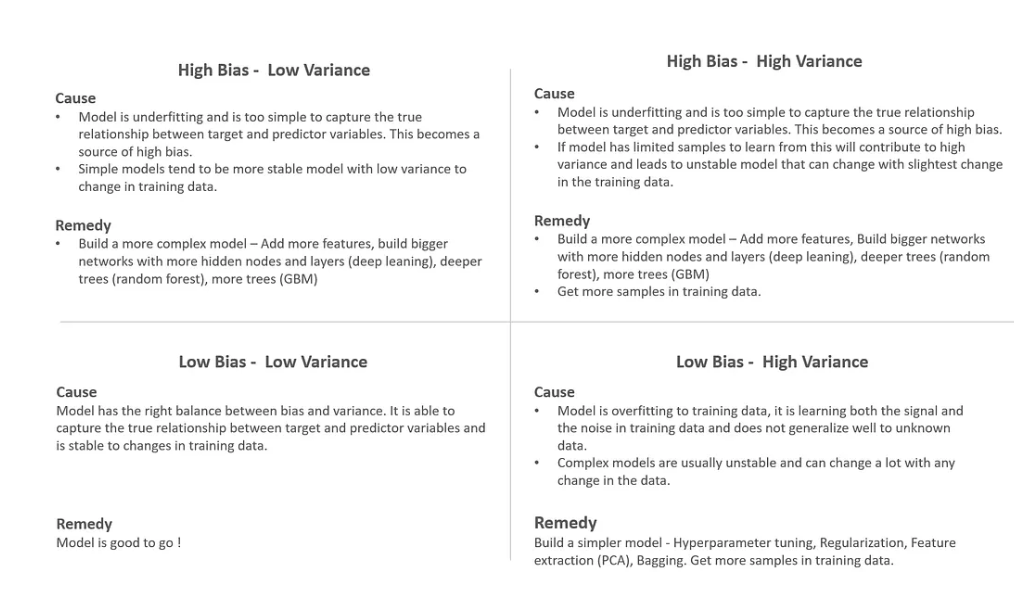


- Simple models usually have high bias and low variance, which may cause underfitting.
- Complex models usually have low bias but high variance, which may cause overfitting.
- Balanced model achieves an optimal point where both bias and variance are reasonably low.
- Goal of machine learning is to minimize the total prediction error on unseen data.

The total prediction error can be expressed as 

TotalError=Bias^2 +Variance+IrreducibleError 

Here:

- Bias²: Error caused by incorrect assumptions in the model.
- Variance: Error caused by sensitivity to training data.
- Irreducible Error: Random noise in the data that cannot be eliminated.

Importance of Bias Variance Tradeoff
Understanding the bias variance tradeoff helps in building better machine learning models.

- Helps models perform well on unseen data.
- Helps choose appropriate algorithms and complexity.
- Helps achieve better model performance.

##### Methods to Manage Bias Variance Trade off:

1. **Cross Validation**

Cross-validation is a technique used to check how well a machine learning model performs on unseen data while preventing overfitting. It works by:

- Splitting the dataset into several parts.
- Training the model on some parts and testing it on the remaining part.
- Repeating this resampling process multiple times by choosing different parts of the dataset.
- Averaging the results from each validation step to get the final performance.


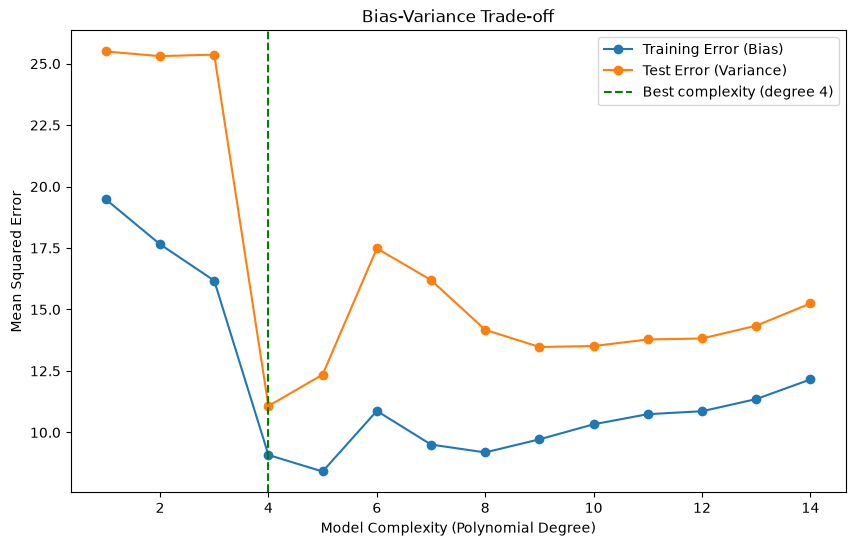

Training errors: [19.48, 17.65, 16.17, 9.08, 8.41, 10.87, 9.51, 9.19, 9.72, 10.33, 10.74, 10.86, 11.36, 12.15]
Test errors: [25.49, 25.31, 25.37, 11.07, 12.35, 17.49, 16.2, 14.17, 13.47, 13.51, 13.78, 13.82, 14.34, 15.24]
Best degree (lowest test error): 4


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate noisy non-linear data
np.random.seed(42)
X = np.sort(np.random.rand(80, 1) * 10, axis=0)
y = 2 * X.ravel() + np.sin(X.ravel()) * 5 + np.random.randn(80) * 3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = range(1, 15)
train_errors = []
test_errors = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker='o', label='Training Error (Bias)')
plt.plot(degrees, test_errors, marker='o', label='Test Error (Variance)')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Trade-off')
plt.legend()
plt.axvline(x=degrees[np.argmin(test_errors)], color='green', linestyle='--', 
            label=f'Best complexity (degree {degrees[np.argmin(test_errors)]})')
plt.legend()
plt.show()

print("Training errors:", [round(e, 2) for e in train_errors])
print("Test errors:", [round(e, 2) for e in test_errors])
print("Best degree (lowest test error):", degrees[np.argmin(test_errors)])

- **Low degree (left side):** both training and test error are high → **underfitting (high bias)**.
- **Middle (sweet spot):** training error drops, test error is at its lowest → **best generalization**.
- **High degree (right side):** training error keeps dropping toward 0, but test error rises sharply → **overfitting (high variance)**.

The green dashed line marks the degree with the lowest test error — that's the ideal complexity for this dataset before regularization is even needed. If you push complexity higher than this, that's exactly when **Ridge/Lasso/Elastic Net** step in to control variance without changing the degree.

### Regularization
#### What is Regularization?
Regularization is a machine learning technique used to **prevent overfitting** by adding a penalty term to the model's loss function.
It helps the model learn important patterns from the data instead of memorizing noise.

#### Without Regularization:
- Model becomes too complex.
- Learns noise from training data.
- Performs poorly on new/unseen data.

#### With Regularization:
- Reduces model complexity.
- Prevents overfitting.
- Improves generalization on unseen data.

---
### Why Do We Use Regularization?
- Reduces overfitting.
- Improves model performance.
- Controls large coefficient values.
- Makes the model simpler and more stable.
- Helps when there are many features.

---
### Types of Regularization
#### 1. L1 Regularization (Lasso Regression)
L1 Regularization adds a penalty based on the **absolute value of coefficients**.

#### Formula:
$$
Loss = MSE + \lambda \sum |\beta|
$$

Where:
- **MSE** = Mean Squared Error
- **β** = Model coefficients
- **λ (lambda)** = Regularization strength

#### Effect:
- Shrinks some coefficients to exactly **zero**.
- Performs feature selection.
- Removes less important features.

#### Example:
Before Lasso:

| Feature | Coefficient |
|---------|-------------|
| Age | 0.8 |
| Income | 0.6 |
| Location | 0.3 |
| Gender | 0.1 |

After Lasso:

| Feature | Coefficient |
|---------|-------------|
| Age | 0.8 |
| Income | 0.6 |
| Location | 0 |
| Gender | 0 |

Features with zero coefficients are removed.

#### Used For:
- Feature selection
- High-dimensional datasets

---
### 2. L2 Regularization (Ridge Regression)
L2 Regularization adds a penalty based on the **square of coefficients**.

#### Formula:
$$
Loss = MSE + \lambda \sum \beta^2
$$

#### Effect:
- Reduces coefficient values.
- Keeps all features in the model.
- Does not make coefficients exactly zero.

#### Example:
Before Ridge:

| Feature | Coefficient |
|---------|-------------|
| Age | 10 |
| Income | 8 |
| Location | 5 |

After Ridge:

| Feature | Coefficient |
|---------|-------------|
| Age | 3 |
| Income | 2 |
| Location | 1 |

#### Used For:
- Multicollinearity problems.
- Datasets with many correlated features.

---
### 3. Elastic Net Regularization
Elastic Net combines both **L1 and L2 Regularization**.

#### Formula:
$$
Loss = MSE + \lambda_1 \sum |\beta| + \lambda_2 \sum \beta^2
$$

#### Effect:
- Performs feature selection like Lasso.
- Handles correlated features like Ridge.
- Provides a balance between L1 and L2.

#### Example:
If we have correlated features:
- Income
- Salary
- Annual Earnings

Lasso may select only one feature.
Elastic Net can keep related features while reducing their impact.

#### Used For:
- Large datasets.
- Datasets with many correlated variables.

---
### Comparison of Regularization Techniques

| Regularization | Penalty | Coefficient Effect | Feature Selection |
|----------------|---------|--------------------|------------------|
| L1 (Lasso) | Absolute value of coefficients | Some coefficients become 0 | Yes |
| L2 (Ridge) | Squared value of coefficients | Shrinks coefficients | No |
| Elastic Net | L1 + L2 | Shrinks and removes features | Yes |

---
### Regularization Parameter (λ)
Lambda controls the amount of penalty.

#### Small λ:
- Less penalty.
- More complex model.
- Higher chance of overfitting.

#### Large λ:
- More penalty.
- Simpler model.
- May cause underfitting.

**Regularization Example**

We'll fit a high-degree polynomial to noisy data — this overfits badly with plain Linear Regression.
Then we'll apply **Ridge (L2)**, **Lasso (L1)**, and **Elastic Net** to fix it.

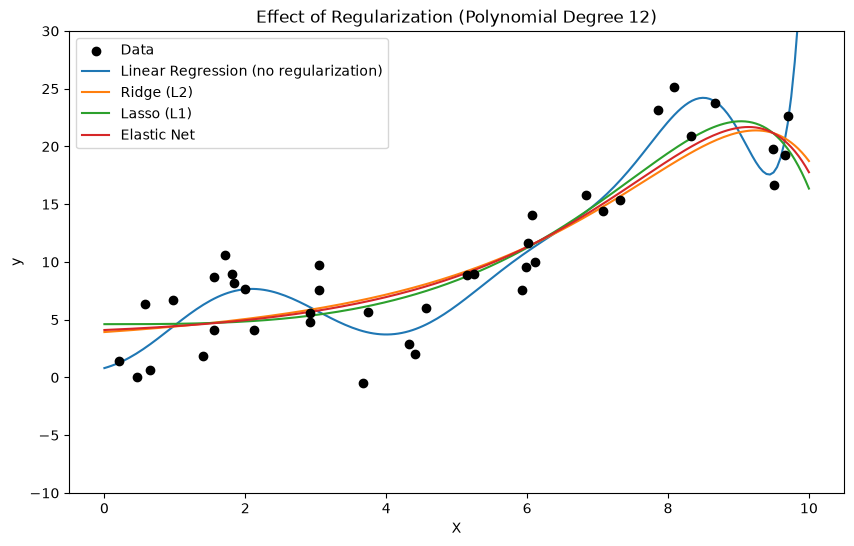

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline

# Generate noisy non-linear data
np.random.seed(42)
X = np.sort(np.random.rand(40, 1) * 10, axis=0)
y = 2 * X.ravel() + np.sin(X.ravel()) * 5 + np.random.randn(40) * 3

degree = 12  # high degree -> prone to overfitting

models = {
    "Linear Regression (no regularization)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), LinearRegression()
    ),
    "Ridge (L2)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=5)
    ),
    "Lasso (L1)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=0.1, max_iter=10000)
    ),
    "Elastic Net": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
    ),
}

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Data', zorder=5)

for name, model in models.items():
    model.fit(X, y)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, label=name)

plt.ylim(-10, 30)
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Effect of Regularization (Polynomial Degree {degree})")
plt.legend()
plt.show()

### What is Multiple Linear Regression?

Multiple Linear Regression (also called **Multilinear Regression**) is an extension of simple linear regression that models the relationship between **one dependent variable (target)** and **two or more independent variables (features)**.

It assumes the target variable can be predicted as a **weighted linear combination** of multiple input features.

**Formula** 
$$
Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \beta_3X_3 + \dots + \beta_nX_n + \epsilon
$$

Where:
- **Y** = Dependent variable (what we're predicting)
- **X₁, X₂, ... Xₙ** = Independent variables (features/predictors)
- **β₀** = Intercept (value of Y when all X = 0)
- **β₁, β₂, ... βₙ** = Coefficients (how much Y changes per unit change in each X)
- **ε (epsilon)** = Error term (captures noise/unexplained variation)

**Example**

Predicting **House Price** using multiple features:

$$
Price = \beta_0 + \beta_1(\text{Size}) + \beta_2(\text{Bedrooms}) + \beta_3(\text{Location Score}) + \epsilon
$$

| Feature | Coefficient (β) | Meaning |
|---------|-----------------|---------|
| Size (sq ft) | 150 | Price increases $150 per sq ft |
| Bedrooms | 5000 | Each extra bedroom adds $5,000 |
| Location Score | 2000 | Each point in location score adds $2,000 |

So a house with Size=1000, Bedrooms=3, Location Score=8:

$$
Price = \beta_0 + (150 \times 1000) + (5000 \times 3) + (2000 \times 8)
$$

##### Key Assumptions
- **Linearity** – Relationship between each X and Y is linear.
- **Independence** – Observations are independent of each other.
- **No/Low Multicollinearity** – Independent variables shouldn't be highly correlated with each other.
- **Homoscedasticity** – Residuals (errors) have constant variance across all levels of X.
- **Normality of Residuals** – Errors are approximately normally distributed.

##### Used For
- Predicting prices (houses, stocks, products) based on multiple factors
- Sales forecasting using multiple business metrics
- Risk scoring using multiple customer attributes
- Any scenario where a target depends on **several interacting variables**



 **Multiple Linear Regression Example**
 
Predicting house price using **Size**, **Bedrooms**, and **Location Score**.

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Sample dataset
data = {
    'Size': [1000, 1500, 1800, 2400, 3000, 3500, 4000, 4500],
    'Bedrooms': [2, 3, 3, 4, 4, 5, 5, 6],
    'Location_Score': [5, 6, 7, 6, 8, 9, 9, 10],
    'Price': [200000, 250000, 280000, 320000, 400000, 450000, 500000, 550000]
}
df = pd.DataFrame(data)

X = df[['Size', 'Bedrooms', 'Location_Score']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Predict a new house
new_house = pd.DataFrame({'Size': [2000], 'Bedrooms': [3], 'Location_Score': [7]})
predicted_price = model.predict(new_house)
print("Predicted Price:", predicted_price[0])

Coefficients: [   105.61456753 -15235.20485584   8391.50227618]
Intercept: 79044.00606980134
R² Score: 0.996695215770434
MSE: 33047842.295660768
Predicted Price: 303308.04248861875


### Polynomial Regression

Polynomial Regression is a type of regression analysis where the relationship between the independent variable(s) X and the dependent variable Y is modeled as an **nth-degree polynomial** rather than a straight line. It's technically still a form of linear regression — because it's linear in terms of the coefficients — but it fits a **curved line** to the data instead of a straight one.

It's used when the data shows a **non-linear pattern** that a straight line can't capture well.

**Formula**

$$
Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \dots + \beta_nX^n + \epsilon
$$

Where:
- **X, X², X³, ... Xⁿ** = the original feature raised to increasing powers
- **β₀, β₁, ... βₙ** = coefficients
- **n** = degree of the polynomial (controls how curvy the fit is)
- **ε** = error term

Why Use It?
- When a **scatter plot** of your data shows a curve (like a U-shape, S-shape, or wave) instead of a straight-line trend.
- When linear regression **underfits** the data (high bias, poor accuracy on both training and test data).
- Common in scenarios like:
  - Growth curves (population, sales growth over time)
  - Physics/engineering relationships (motion, temperature change)
  - Any data with diminishing or accelerating returns

**Example**

Predicting a car's stopping distance based on speed — the relationship isn't linear (distance grows much faster than speed increases), so you might fit:

$$
Distance = \beta_0 + \beta_1(Speed) + \beta_2(Speed)^2
$$

This captures the curve much better than a straight line would.

**Degree Selection**

Degree Selection — The Key Risk
- **Low degree (e.g., degree 1)** → basically linear regression, may **underfit**.
- **Moderate degree** → captures the true curve well.
- **Too high degree** → the curve starts wiggling to hit every data point exactly → **overfitting** (great on training data, terrible on new data).

This is where **regularization (Ridge, Lasso, Elastic Net)** becomes important again — it helps control the coefficients of higher-degree terms so the model doesn't overfit.

###### Polynomial vs Linear vs Multiple Linear Regression

| Aspect | Linear Regression | Multiple Linear Regression | Polynomial Regression |
|---|---|---|---|
| Relationship | Straight line | Straight line (multiple features) | Curved line |
| Features used | 1 | 2+ | Powers of 1 (or more) feature(s) |
| Best for | Simple linear trends | Multiple linear-contributing factors | Non-linear/curved trends |

**Polynomial Regression Example**

Predicting stopping distance from speed (non-linear relationship).

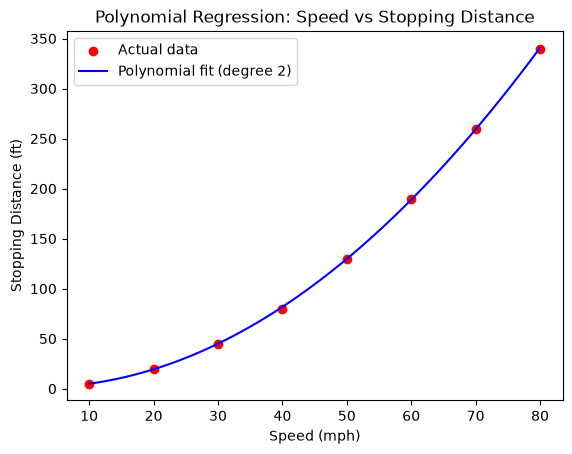

Predicted stopping distance at 55 mph: 157.9464285714285


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Sample data: speed (mph) vs stopping distance (ft)
speed = np.array([10, 20, 30, 40, 50, 60, 70, 80]).reshape(-1, 1)
distance = np.array([5, 20, 45, 80, 130, 190, 260, 340])

# Fit polynomial regression (degree 2)
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(speed, distance)

# Predict across a smooth range for plotting
speed_range = np.linspace(10, 80, 100).reshape(-1, 1)
predicted_distance = poly_model.predict(speed_range)

# Plot
plt.scatter(speed, distance, color='red', label='Actual data')
plt.plot(speed_range, predicted_distance, color='blue', label=f'Polynomial fit (degree {degree})')
plt.xlabel('Speed (mph)')
plt.ylabel('Stopping Distance (ft)')
plt.title('Polynomial Regression: Speed vs Stopping Distance')
plt.legend()
plt.show()

# Predict stopping distance at speed = 55 mph
predicted = poly_model.predict([[55]])
print("Predicted stopping distance at 55 mph:", predicted[0])